In [59]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [61]:
housing = pd.read_csv("C:/Users/User\OneDrive/nimra tayyaba/housing.csv")

First 5 rows


In [62]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Check shape

In [63]:
housing.shape

(20640, 10)

Missing Values

In [64]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Check Missing values

In [65]:
housing['total_bedrooms'].fillna(housing['total_bedrooms'].mean(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_12112\1120270243.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing['total_bedrooms'].fillna(housing['total_bedrooms'].mean(), inplace=True)


Handle missing values

In [66]:
housing.drop_duplicates(inplace=True)

Remove Duplicate

In [67]:
housing.duplicated().sum()

np.int64(0)

In [68]:
housing_log = housing.copy()

numeric_columns = housing.select_dtypes(include=[np.number]).columns

for col in numeric_columns:
    housing_log[col] = np.log2(housing[col] + 1)

c:\Users\User\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


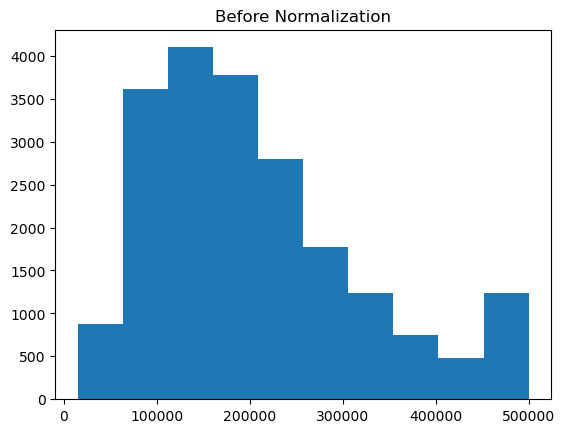

In [69]:
plt.hist(housing['median_house_value'])
plt.title("Before Normalization")
plt.show()

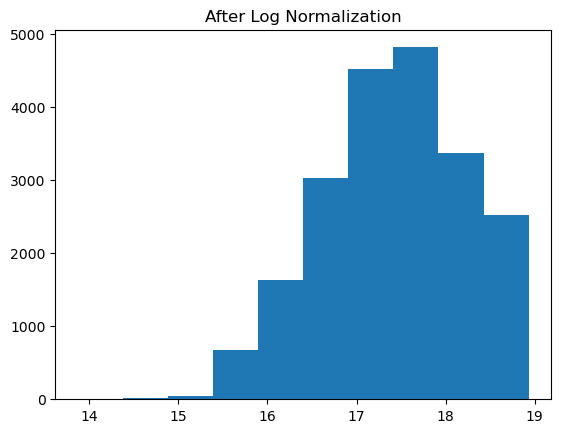

In [70]:
plt.hist(housing_log['median_house_value'])
plt.title("After Log Normalization")
plt.show()

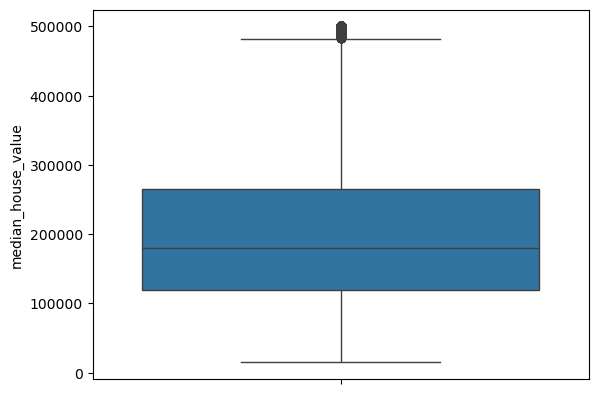

In [71]:
sns.boxplot(housing['median_house_value'])
plt.show()

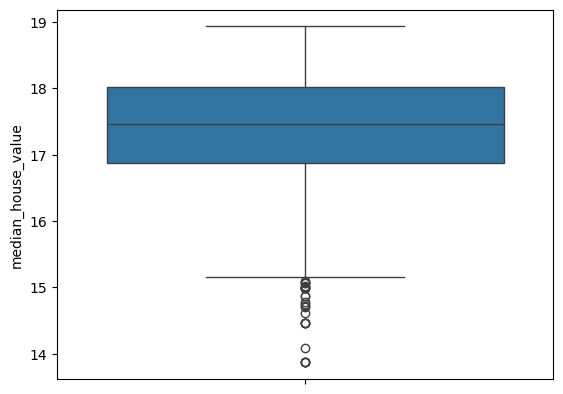

In [72]:
sns.boxplot(housing_log['median_house_value'])
plt.show()

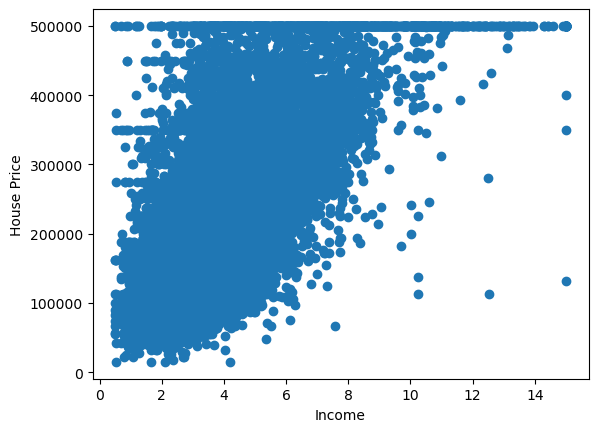

In [74]:
plt.scatter(housing['median_income'],housing['median_house_value'])
plt.xlabel("Income")
plt.ylabel("House Price")
plt.show()

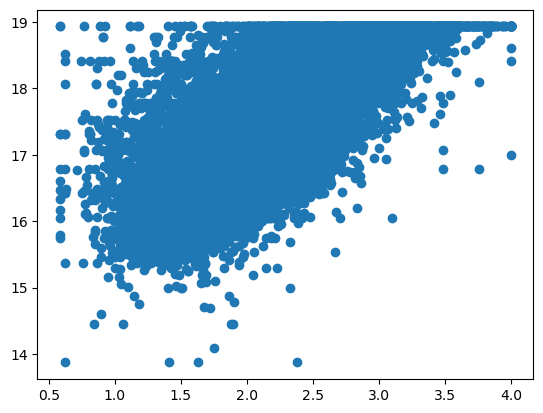

In [75]:
plt.scatter(housing_log['median_income'],housing_log['median_house_value'])
plt.show()

In [76]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [77]:
housing.mean(numeric_only=True)


longitude               -119.569704
latitude                  35.631861
housing_median_age        28.639486
total_rooms             2635.763081
total_bedrooms           537.870553
population              1425.476744
households               499.539680
median_income              3.870671
median_house_value    206855.816909
dtype: float64

In [81]:
housing.std(numeric_only=True)

longitude                  2.003532
latitude                   2.135952
housing_median_age        12.585558
total_rooms             2181.615252
total_bedrooms           419.266592
population              1132.462122
households               382.329753
median_income              1.899822
median_house_value    115395.615874
dtype: float64

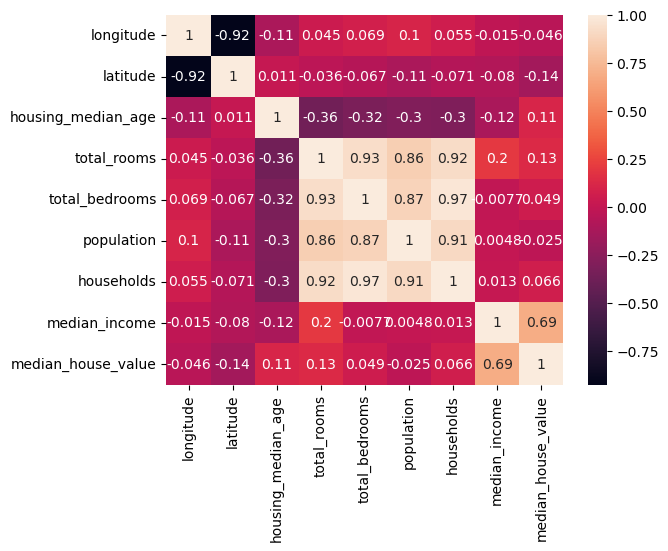

In [82]:
numeric_data = housing.select_dtypes(include=['number'])

corr = numeric_data.corr()

sns.heatmap(corr, annot=True)

plt.show()

In [83]:
corr = housing.select_dtypes(include=['number']).corr()

corr['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049454
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

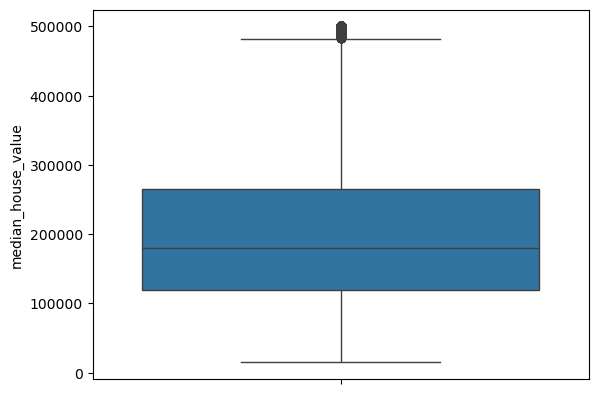

In [84]:
sns.boxplot(housing['median_house_value'])
plt.show()